# INF-0616 - Projeto 3: Redes neurais

Professora: Esther Colombini -- esther@ic.unicamp.br

Monitores: Alana Santana -- a229999@dac.unicamp.br
           Hudson Bruno -- hudson.bruno@ic.unicamp.br 

Este *notebook* faz parte da disciplina INF-0616 no curso de extensão MDC.  
Demais artefatos podem ser encontrados no moodle da disciplina: 
[moodle.lab.ic.unicamp.br](https://moodle.lab.ic.unicamp.br/moodle/course/view.php?id=456)

Download do dataset: [download dataset customer-issues](https://ic.unicamp.br/~esther/customer-issues.csv)

Instituto de Computação - Unicamp 2020

Alunos: 
Danilo Xavier Silva e 
Patrícia Cristina Fernandes

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD

from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(12049)

plt.rcParams['figure.figsize'] = (12, 6)

#### Lendo o conjunto de dados

O conjunto de dados consiste em reclamações de clientes a cerca de produtos/serviços oferecidos em uma instituição bancária. ***Garanta que o arquivo*** `customer-issues.csv` ***está no mesmo diretório do notebook***.

In [3]:
d = pd.read_csv('./customer-issues.csv')
display(d.head())

,date-received,product,sub-product,issue,sub-issue,consumer-message,state,zip-code,tags,via,resolution,timely-response?,disputed?,complaint-id
0,10/1/2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,AL,352XX,NaN,Web,Closed with explanation,Yes,No,2141773
1,10/17/2016,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,PA,177XX,Older American,Web,Closed with explanation,Yes,No,2163100
2,6/15/2015,Credit reporting,NaN,Credit reporting company's investigation,Inadequate help over the phone,An account on my credit report has a mistaken ...,VA,224XX,NaN,Web,Closed with explanation,Yes,No,1420702
3,2/3/2016,Debt collection,"Other (i.e. phone, health club, etc.)",Disclosure verification of debt,Not given enough info to verify debt,This company refuses to provide me verificatio...,TX,752XX,NaN,Web,Closed with explanation,Yes,Yes,1772196
4,2/17/2016,Debt collection,Credit card,Improper contact or sharing of info,Talked to a third party about my debt,This complaint is in regards to Square Two Fin...,NE,693XX,NaN,Web,Closed with explanation,Yes,Yes,1790634


##### Exibindo as quatro primeiras mensagens

In [4]:
print(*d.loc[:4, 'consumer-message'], sep='\n\n')

I have outdated information on my credit report that I have previously disputed that has yet to be removed this information is more then seven years old and does not meet credit reporting requirements

I purchased a new car on XXXX XXXX. The car dealer called Citizens Bank to get a 10 day payoff on my loan, good till XXXX XXXX. The dealer sent the check the next day. When I balanced my checkbook on XXXX XXXX. I noticed that Citizens bank had taken the automatic payment out of my checking account at XXXX XXXX XXXX Bank. I called Citizens and they stated that they did not close the loan until XXXX XXXX. ( stating that they did not receive the check until XXXX. XXXX. ). I told them that I did not believe that the check took that long to arrive. XXXX told me a check was issued to me for the amount overpaid, they deducted additional interest. Today ( XXXX XXXX, ) I called Citizens Bank again and talked to a supervisor named XXXX, because on XXXX XXXX. I received a letter that the loan had b

##### Extraíndo um conjunto de testes válido

As mensagens contidas neste conjunto possuem uma relação temporal.
É importante realizar a separação dos sub-conjuntos de treino/teste respeitando esta relação, de forma a garantir que o modelo não seja treinado sobre amostras no futuro e experimentado sobre o passado.

In [5]:
d.sort_values(by='date-received', inplace=True)

### Modelando a classificação de tópicos baseado nas mensagens de clientes

Observando no gráfico de frequências de produto sobre as conversas que este é um problema extremamente desbalanceado. Há, entretanto, amostras suficientes para a modelagem de um estimador de tópico (de produto) levando em consideração o diálogo do cliente.

In [6]:
def frequencies(dataset, column):
    labels, counts = np.unique(dataset[column], return_counts=True)
    p = np.argsort(counts)[::-1]
    labels, counts = labels[p], counts[p]
    
    (sns
     .barplot([l[:40] for l in labels], counts)
     .set_title(f'Occurrences for The {len(labels)} Classes in {column}'))
    plt.xticks(rotation=90)
    
    return labels, counts

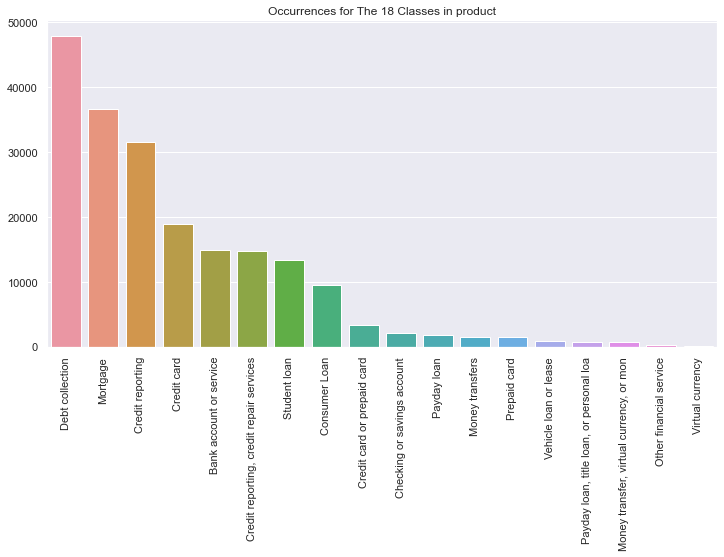

In [7]:
labels, counamts = frequencies(d, 'product')

Simplificamos o problema, considerando somente as 6 classes mais frequentes:

In [8]:
s = d['product'].isin(labels[:6])
d = d[s]

test_share = .3

d_train, d_test = train_test_split(d, test_size=test_share, shuffle=False)
assert d_train['date-received'].max() <= d_test['date-received'].min()

x_train, x_test = d_train['consumer-message'], d_test['consumer-message']
y_train, y_test = d_train['product'], d_test['product']

Vamos codificar as palavras na conversa utilizando o TF-IDF, gerando um vetor de características baseadas nas frequências de ocorrência das palavras no documento e em todo o conjunto de dados.

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

features = 1024

encoder = make_pipeline(TfidfVectorizer(min_df=5,
                                        stop_words='english',
                                        strip_accents='unicode',
                                        max_features=features),
                        StandardScaler(with_mean=False))

x_train = encoder.fit_transform(x_train)
x_test = encoder.transform(x_test)

label_enc = LabelEncoder()
ye_train = label_enc.fit_transform(y_train)
ye_test = label_enc.transform(y_test)

## Treinando um regressor logístico para classificar produto
**Atividade (1 pt):** treine um regressor logístico, buscando os hiper-parâmetros com *grid-search*.

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [11]:
lr = LogisticRegression(random_state=42, max_iter=3000)
param_grid = dict(C=np.logspace(-3, 2, 6))

# Busca de hiper parametros
g = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', verbose=3)
g.fit(x_train, ye_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END ...........................C=0.001;, score=0.826 total time=  20.6s
[CV 2/5] END ...........................C=0.001;, score=0.830 total time=  11.0s
[CV 3/5] END ...........................C=0.001;, score=0.821 total time=   8.5s
[CV 4/5] END ...........................C=0.001;, score=0.823 total time=  10.4s
[CV 5/5] END ...........................C=0.001;, score=0.819 total time=   9.3s
[CV 1/5] END ............................C=0.01;, score=0.824 total time=  12.6s
[CV 2/5] END ............................C=0.01;, score=0.829 total time=  12.2s
[CV 3/5] END ............................C=0.01;, score=0.820 total time=  12.4s
[CV 4/5] END ............................C=0.01;, score=0.823 total time=  12.7s
[CV 5/5] END ............................C=0.01;, score=0.818 total time=  12.4s
[CV 1/5] END .............................C=0.1;, score=0.822 total time=  20.3s
[CV 2/5] END .............................C=0.1;,

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=3000, random_state=42),
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])},
             scoring='accuracy', verbose=3)

In [12]:
print(
    "Melhor Score:        %.5f" % (g.best_score_),
    "Melhores Parametros: %s"   % (g.best_params_),
    sep='\n'
)

Melhor Score:        0.82377
Melhores Parametros: {'C': 0.001}


In [13]:
# Predição
regressor = LogisticRegression(C=g.best_params_['C']).fit(x_train, ye_train)

prediction  = regressor.predict(x_test)

print("Melhor Modelo:")
print("MSE = %.5f" %  (accuracy_score(ye_test, prediction)))

Melhor Modelo:
MSE = 0.75682


Iremos calcular a matriz de confusão relativa $R$, que guarda porcentagens de incidências em vez das contagens absolutas, e plotar o heatmap dessa matriz. Além disso, iremos calcular a distribuição de confiança nas predições por classe (mais próximos de `1.0` --> mais confiante):

In [14]:
def evaluate(y, p, probabilities, labels=None):
    # Cálculo das métricas de acerto.
    print('Accuracy:', metrics.accuracy_score(y, p).round(3))
    print('Accuracy (balanced):', metrics.balanced_accuracy_score(y, p).round(3))
    
    # Calculo da matriz de confusão.
    c = metrics.confusion_matrix(y, p)
    r = c / c.sum(axis=1, keepdims=True)
    
    # Impressão dos gráficos.
    (plt
     .figure(figsize=(16, 12))
     .suptitle('Matriz de confusão', fontsize=20))
    sns.heatmap(r,
                cmap="YlGnBu", linewidths=.5, annot=True, fmt=".1%",
                xticklabels=labels, yticklabels=labels, cbar=False)

    (plt
     .figure(figsize=(16, 12))
     .suptitle('Distribuição de confiança para cada classe', fontsize=20))
    
    for i in np.unique(y):
        # Para cada classe `i`, seleciona suas amostras e filtra a confiança
        # do modelo em predizer estas amostras como sendo da classe `i`.
        sns.distplot(probabilities[y.ravel() == i][:, i],
                     hist=False,
                     label=labels[i])

Vamos utilizar a função `evaluate` para avaliar o modelo treinado anteriormente:

Accuracy: 0.757
Accuracy (balanced): 0.733


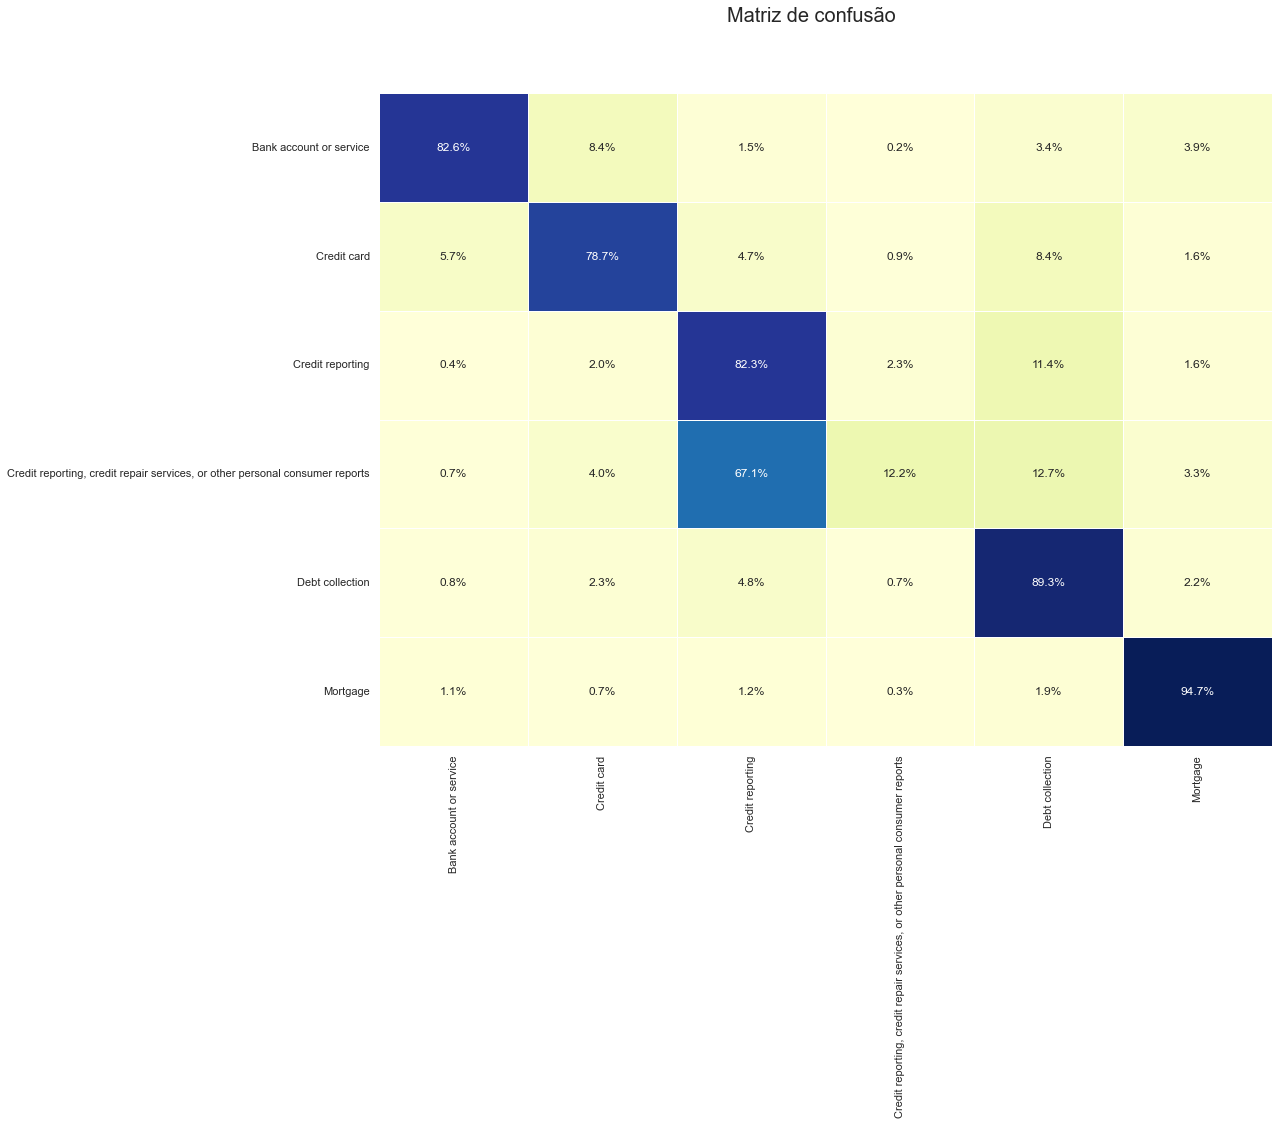

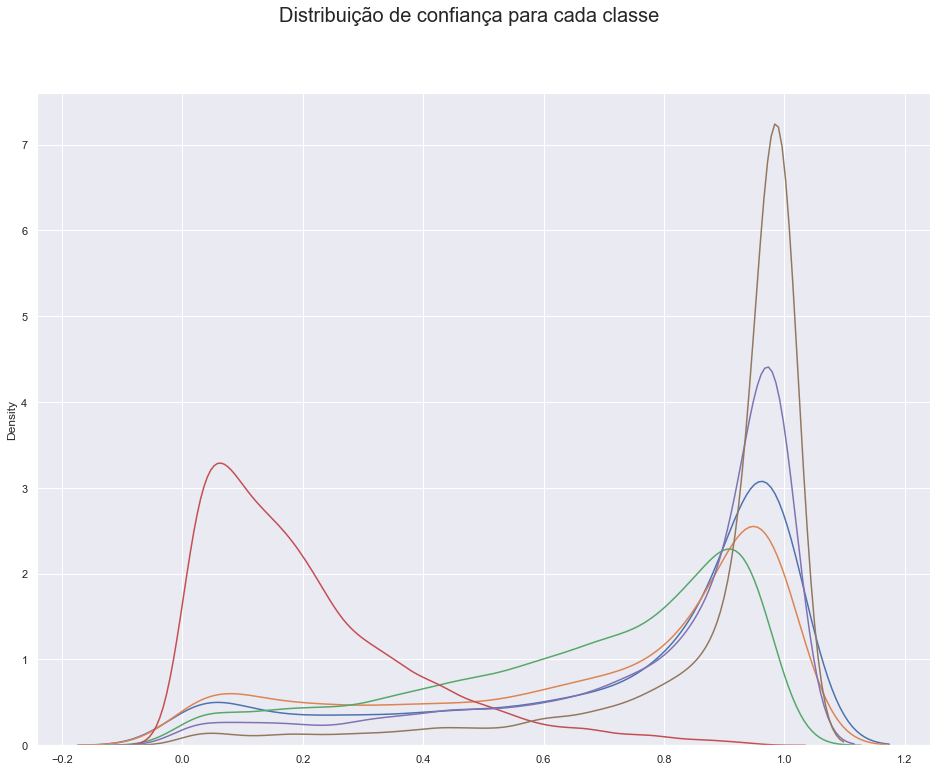

In [15]:
evaluate(ye_test, g.predict(x_test), g.predict_proba(x_test), labels=label_enc.classes_)

**Pergunta (1pt):** considerando o gráfico de distribuição de confiança para o seu modelo treinado, as amostras são classificadas com alta confiança? Há uma grande diferença de confiança entre as diferentes classes?

A maior parte das classes estão com a confiança acima de 0.9, o que classificam elas como altamente confiável. Porém uma classe isolada se mostra com a confiança muito baixa perto de 0.

possível observar que, entre as classes mais confiáveis, há uma relação de quanto mais denso a classe, maior é a confiança na classificação.

----------
----------

## Redes Neurais
Iremos treinar alguns modelos de redes neurais, variando número de camadas e quantidade de neurônios em cada camada.

In [16]:
epochs = 3
batch_size = 128
input_shape = [features]

Vamos converter os rótulos em vetores *One Hot Encoded*:

In [17]:
from keras.utils import np_utils
y_ohe_train = np_utils.to_categorical(ye_train, num_classes=6)
y_ohe_test = np_utils.to_categorical(ye_test, num_classes=6)

**Atividade (1 pt):** defina uma arquitetura de uma rede neural capaz de classificar os diferentes produtos a partir da conversa dos clientes. Compile a sua rede com a loss `categorical_crossentropy`, optimizador `SGD` e defina as métricas relevantes para o problema. 

In [18]:
from keras import Sequential
from keras.layers import InputLayer, Dense

In [19]:
model = Sequential([
    InputLayer((1024,)),
    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(6, activation="sigmoid")
])

model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 512)               524800    
_________________________________________________________________
dense_1 (Dense)              (None, 256)               131328    
_________________________________________________________________
dense_2 (Dense)              (None, 6)                 1542      
Total params: 657,670
Trainable params: 657,670
Non-trainable params: 0
_________________________________________________________________


### Treinando a rede neural

**Atividade (1 pt):** treine o modelo definido acima sobre o conjunto, respeitando as seguintes regras:

1. Separe um subconjunto do treino para validação.
2. Utilize alguma técnica para conservar os parâmetros que melhor generalizam o problema, como `ModelCheckpoint` (salve o modelo com nome de `weights.h5`).

In [20]:
import tensorflow as tf
from keras import callbacks

In [21]:
device = '/cpu:0'  # ou '/gpu:0'

epochs = 10 # ou 20, 30, 60, 70...
validation_split = .3

with tf.device(device):
    model.fit(x_train.toarray(), y_ohe_train,
              epochs=epochs,
              batch_size=batch_size,
              validation_split=validation_split,
              verbose=1,
              callbacks=[
                  callbacks.TerminateOnNaN(),
                  callbacks.ModelCheckpoint('weights.h5',
                                            save_best_only=True,
                                            verbose=1),
              ])

Epoch 1/10
630/630 [==============================] - 4s 5ms/step - loss: 0.8383 - accuracy: 0.7142 - val_loss: 1.1835 - val_accuracy: 0.6855

Epoch 00001: val_loss improved from inf to 1.18355, saving model to weights.h5
Epoch 2/10
630/630 [==============================] - 3s 5ms/step - loss: 0.5038 - accuracy: 0.8403 - val_loss: 1.0888 - val_accuracy: 0.7000

Epoch 00002: val_loss improved from 1.18355 to 1.08877, saving model to weights.h5
Epoch 3/10
630/630 [==============================] - 3s 5ms/step - loss: 0.4389 - accuracy: 0.8607 - val_loss: 1.0509 - val_accuracy: 0.7088

Epoch 00003: val_loss improved from 1.08877 to 1.05087, saving model to weights.h5
Epoch 4/10
630/630 [==============================] - 4s 6ms/step - loss: 0.4013 - accuracy: 0.8726 - val_loss: 1.0210 - val_accuracy: 0.7087

Epoch 00004: val_loss improved from 1.05087 to 1.02105, saving model to weights.h5
Epoch 5/10
630/630 [==============================] - 4s 6ms/step - loss: 0.3742 - accuracy: 0.8808 

In [22]:
model.load_weights('weights.h5')

O método `model.fit` retorna `model.history`, e contem algumas informações interessantes a respeito do histórico de treinamento.

**Atividade (1 pt):** plote um gráfico de linhas exibindo a evolução dos valores da função *loss* sobre o conjunto de treino e validação. A partir de qual `epoch` a rede começou a super-especializar?

In [23]:
history_f = pd.DataFrame(model.history.history)
history_f

,loss,accuracy,val_loss,val_accuracy
0,0.838279,0.714156,1.183546,0.685493
1,0.503803,0.840298,1.088769,0.699997
2,0.438867,0.860695,1.050868,0.708769
3,0.401336,0.872618,1.021046,0.708682
4,0.374169,0.880806,1.041567,0.712677
5,0.351761,0.888114,1.026559,0.712966
6,0.331780,0.894181,1.045067,0.712330
7,0.313799,0.901079,1.076185,0.713516
8,0.296322,0.907506,1.063161,0.713893
9,0.279639,0.914057,1.081043,0.713574


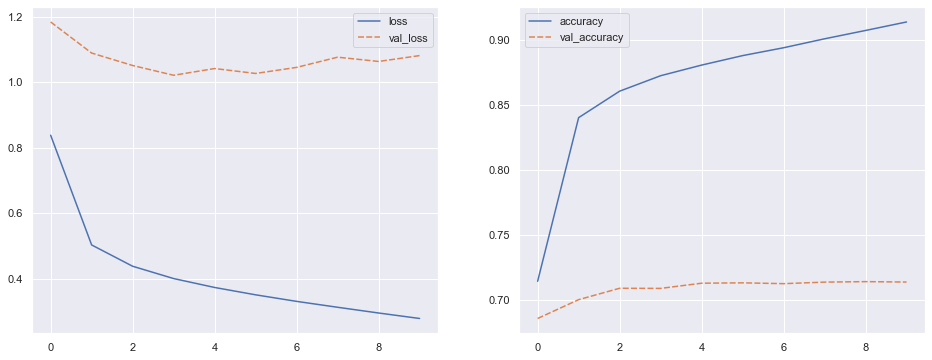

In [24]:
plt.figure(figsize=(16, 6))
plt.subplot(121)
sns.lineplot(data=history_f.loc[:10, ['loss', 'val_loss']])

plt.subplot(122)
sns.lineplot(data=history_f.loc[:30, ['accuracy', 'val_accuracy']]);

**Overfitting**: Podemos observar que a partir da epoch 3, o valor de loss para validação começou a aumentar enquanto o valor de loss para o conjunto de treino continuou a diminuir. Além disso, é possível observar que o valor de acurácia de validação não sofreu diferença considerável a partir da epoch 2, enquanto a acurácia do conjunto de treino subia. Por isso podemos apontar as epochs a partir do número 4 como overfitting.

### Avaliando o modelo treinado

**Atividade (1 pt):** teste o modelo treinado utilizando o subconjunto de teste. Reporte a acurácia para cada classe e a matriz de confusão percentual (usando a função `evaluate` definida anteriormente).

In [25]:
from sklearn.metrics import confusion_matrix, classification_report

probabilities = model.predict(x_test.toarray())
predictions = probabilities.argmax(axis=1)

print(classification_report(ye_test, predictions))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      4058
           1       0.69      0.78      0.73      4902
           2       0.49      0.83      0.62      8604
           3       0.40      0.00      0.00      7620
           4       0.81      0.86      0.84     13884
           5       0.90      0.93      0.91     10279

    accuracy                           0.72     49347
   macro avg       0.68      0.70      0.65     49347
weighted avg       0.70      0.72      0.67     49347



In [26]:
# acurácia para cada classe
matrix = confusion_matrix(y_ohe_test.argmax(axis=1), probabilities.argmax(axis=1))
(matrix.diagonal()/matrix.sum(axis=1)).round(3)

array([0.8  , 0.778, 0.826, 0.   , 0.863, 0.926])

Accuracy: 0.723
Accuracy (balanced): 0.699


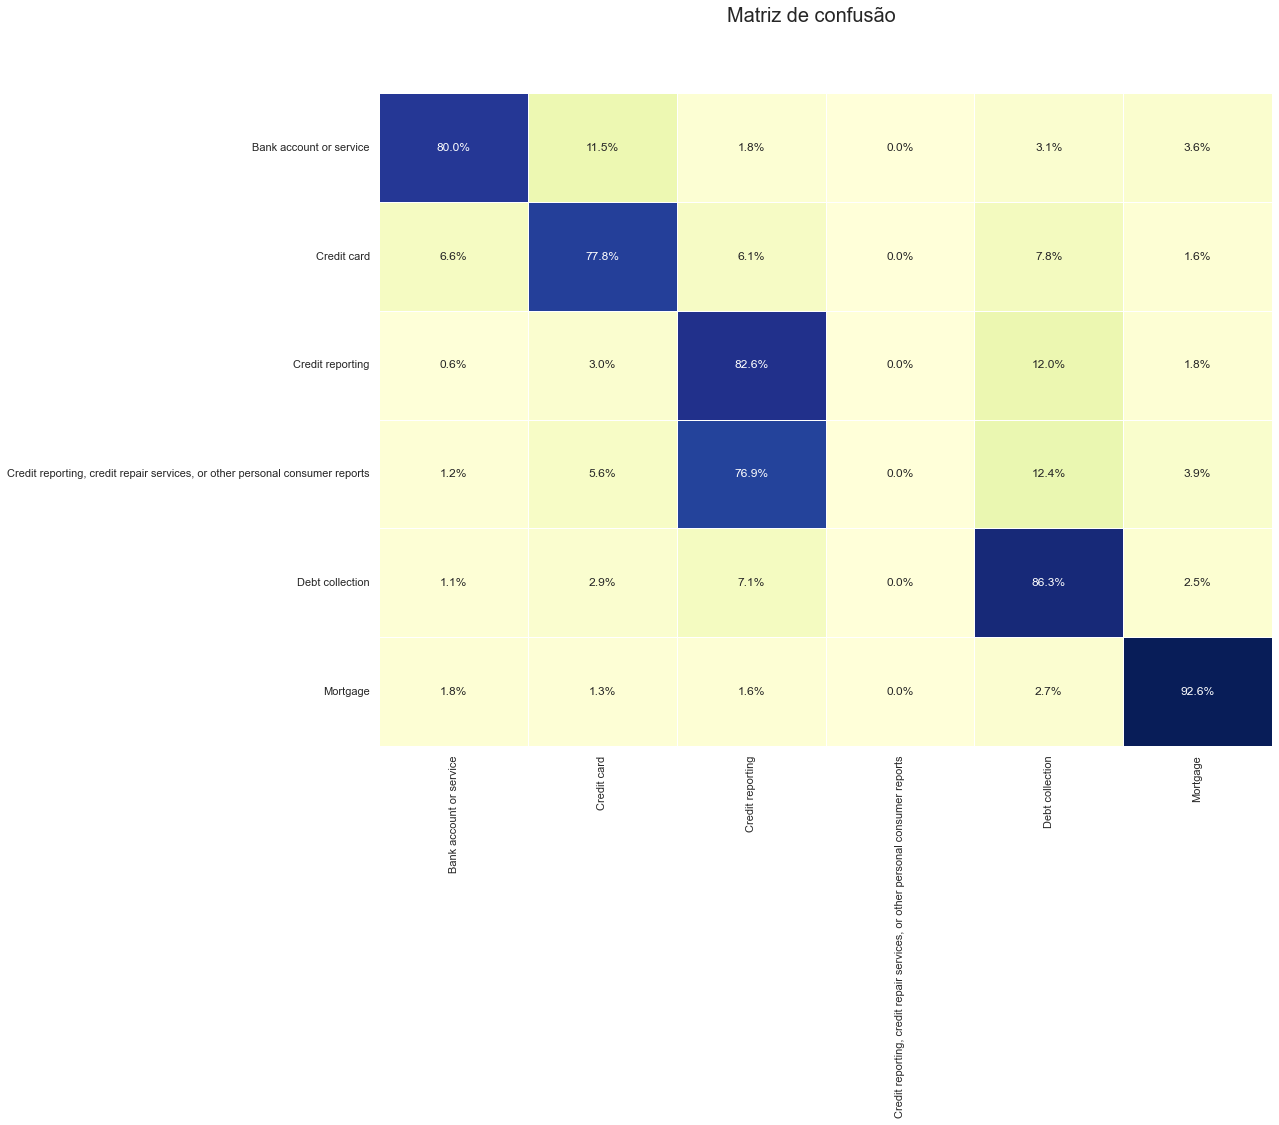

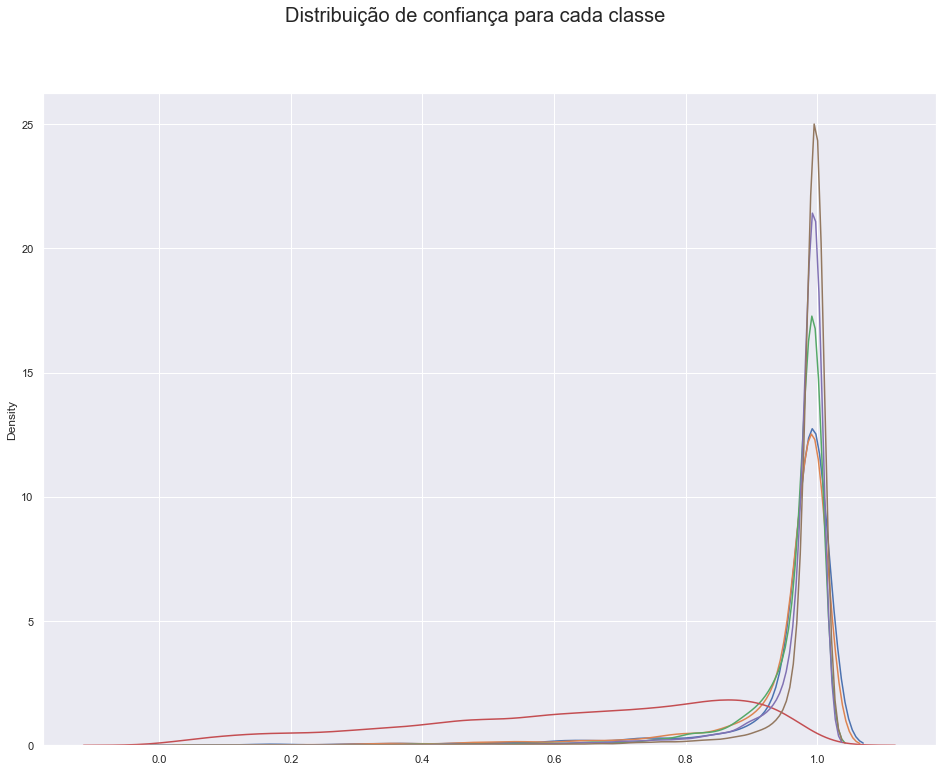

In [27]:
# Matriz de Confusão
evaluate(y_ohe_test.argmax(axis=1), predictions, probabilities, labels=label_enc.classes_)

--------

Repita agora a definição, treinamento e avaliação de uma rede neural mais complexa, aumentando o número de camadas ou a quantidade de neurônios nas camadas da rede anterior:

**Atividade (1 pt):** defina uma rede neural mais complexa e a compile com as mesmas configurações da rede anterior.

In [28]:
model_complex = Sequential([
    InputLayer((1024,)),
    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(6, activation="sigmoid")
])

model_complex.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_complex.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 512)               524800    
_________________________________________________________________
dense_4 (Dense)              (None, 256)               131328    
_________________________________________________________________
dense_5 (Dense)              (None, 128)               32896     
_________________________________________________________________
dense_6 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_7 (Dense)              (None, 6)                 390       
Total params: 697,670
Trainable params: 697,670
Non-trainable params: 0
_________________________________________________________________


**Atividade (1 pt):** treine a nova rede.

In [29]:
with tf.device(device):
    model_complex.fit(x_train.toarray(), y_ohe_train,
              epochs=epochs,
              batch_size=batch_size,
              validation_split=validation_split,
              verbose=1,
              callbacks=[
                  callbacks.TerminateOnNaN(),
                  callbacks.ModelCheckpoint('weights_2.h5',
                                            save_best_only=True,
                                            verbose=1),
              ])

Epoch 1/10
630/630 [==============================] - 4s 6ms/step - loss: 0.9752 - accuracy: 0.6469 - val_loss: 1.2546 - val_accuracy: 0.6739

Epoch 00001: val_loss improved from inf to 1.25461, saving model to weights_2.h5
Epoch 2/10
630/630 [==============================] - 4s 6ms/step - loss: 0.5195 - accuracy: 0.8336 - val_loss: 1.0855 - val_accuracy: 0.6974

Epoch 00002: val_loss improved from 1.25461 to 1.08549, saving model to weights_2.h5
Epoch 3/10
630/630 [==============================] - 4s 6ms/step - loss: 0.4408 - accuracy: 0.8592 - val_loss: 1.0549 - val_accuracy: 0.7043

Epoch 00003: val_loss improved from 1.08549 to 1.05485, saving model to weights_2.h5
Epoch 4/10
630/630 [==============================] - 4s 6ms/step - loss: 0.3976 - accuracy: 0.8737 - val_loss: 0.9866 - val_accuracy: 0.7079

Epoch 00004: val_loss improved from 1.05485 to 0.98658, saving model to weights_2.h5
Epoch 5/10
630/630 [==============================] - 4s 6ms/step - loss: 0.3655 - accuracy:

In [30]:
model_complex.load_weights('weights_2.h5')

history_c = pd.DataFrame(model_complex.history.history)
history_c

,loss,accuracy,val_loss,val_accuracy
0,0.975160,0.646898,1.254614,0.673885
1,0.519524,0.833573,1.085490,0.697450
2,0.440791,0.859169,1.054853,0.704282
3,0.397645,0.873697,0.986583,0.707871
4,0.365498,0.883945,1.055819,0.707177
5,0.338935,0.892481,0.986303,0.711490
6,0.314752,0.900645,1.014061,0.708132
7,0.291456,0.907829,1.014532,0.711085
8,0.269104,0.915310,1.075134,0.706887
9,0.246555,0.923834,1.076789,0.707900


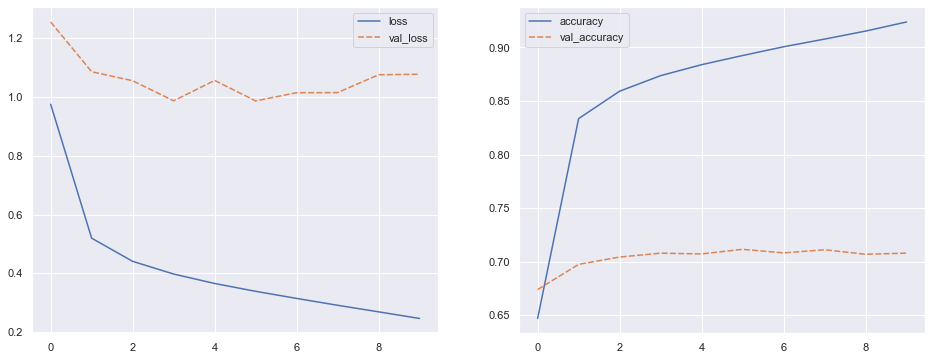

In [31]:
plt.figure(figsize=(16, 6))
plt.subplot(121)
sns.lineplot(data=history_c.loc[:10, ['loss', 'val_loss']])

plt.subplot(122)
sns.lineplot(data=history_c.loc[:30, ['accuracy', 'val_accuracy']]);

**Atividade (1 pt):** adicione dropout ou regularização L1/L2 e treine o novo modelo. Se for, preciso, faça uma busca pelos hipeparâmetros da regularização/dropout.

In [32]:
from tensorflow.keras.regularizers import l1_l2
from keras.layers import Dropout
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

In [33]:
def get_model(l1, l2):
    model = Sequential()
    model.add(Dense(6, activation='sigmoid', kernel_regularizer=l1_l2(l1=l1, l2=l2)))
    model.compile(loss='categorical_crossentropy',optimizer='sgd', metrics=['accuracy'])
    return model

param_grid = {
    'l1': np.logspace(-5, -1, 5),
    'l2': np.logspace(-5, -1, 5)
}

my_classifier = KerasClassifier(get_model, batch_size=batch_size)
grid = GridSearchCV(my_classifier, param_grid, verbose=2)

grid.fit(x_train.toarray(), y_ohe_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
180/180 [==============================] - 0s 811us/step - loss: 0.5944 - accuracy: 0.8130
[CV] END .................................l1=1e-05, l2=1e-05; total time=   1.9s
180/180 [==============================] - 0s 758us/step - loss: 0.5776 - accuracy: 0.8187
[CV] END .................................l1=1e-05, l2=1e-05; total time=   2.1s
180/180 [==============================] - 0s 755us/step - loss: 0.5925 - accuracy: 0.8095
[CV] END .................................l1=1e-05, l2=1e-05; total time=   1.7s
180/180 [==============================] - 0s 802us/step - loss: 0.7177 - accuracy: 0.7609
[CV] END .................................l1=1e-05, l2=1e-05; total time=   1.7s
180/180 [==============================] - 0s 701us/step - loss: 1.1092 - accuracy: 0.6727
[CV] END .................................l1=1e-05, l2=1e-05; total time=   1.6s
180/180 [==============================] - 0s 736us/step - loss: 0.5883 - accu

180/180 [==============================] - 0s 773us/step - loss: 0.6068 - accuracy: 0.8189
[CV] END ...............................l1=0.0001, l2=0.0001; total time=   1.7s
180/180 [==============================] - 0s 744us/step - loss: 0.5965 - accuracy: 0.8137
[CV] END ...............................l1=0.0001, l2=0.0001; total time=   1.6s
180/180 [==============================] - 0s 769us/step - loss: 0.6103 - accuracy: 0.8094
[CV] END ...............................l1=0.0001, l2=0.0001; total time=   1.8s
180/180 [==============================] - 1s 838us/step - loss: 0.7443 - accuracy: 0.7581
[CV] END ...............................l1=0.0001, l2=0.0001; total time=   2.2s
180/180 [==============================] - 0s 754us/step - loss: 1.1117 - accuracy: 0.6772
[CV] END ...............................l1=0.0001, l2=0.0001; total time=   2.0s
180/180 [==============================] - 0s 810us/step - loss: 0.6178 - accuracy: 0.8099
[CV] END ................................l1=0.000

180/180 [==============================] - 0s 676us/step - loss: 0.7333 - accuracy: 0.8251
[CV] END .................................l1=0.001, l2=0.001; total time=   1.6s
180/180 [==============================] - 0s 764us/step - loss: 0.7561 - accuracy: 0.8146
[CV] END .................................l1=0.001, l2=0.001; total time=   1.6s
180/180 [==============================] - 0s 675us/step - loss: 0.8702 - accuracy: 0.7690
[CV] END .................................l1=0.001, l2=0.001; total time=   2.1s
180/180 [==============================] - 0s 785us/step - loss: 1.2228 - accuracy: 0.6813
[CV] END .................................l1=0.001, l2=0.001; total time=  14.7s
180/180 [==============================] - 0s 698us/step - loss: 0.7854 - accuracy: 0.8300
[CV] END ..................................l1=0.001, l2=0.01; total time=   1.6s
180/180 [==============================] - 0s 785us/step - loss: 0.7677 - accuracy: 0.8301
[CV] END ..................................l1=0.0

180/180 [==============================] - 0s 980us/step - loss: 0.9805 - accuracy: 0.8460
[CV] END ...................................l1=0.01, l2=0.01; total time=   1.8s
180/180 [==============================] - 0s 706us/step - loss: 1.0977 - accuracy: 0.7699
[CV] END ...................................l1=0.01, l2=0.01; total time=   1.7s
180/180 [==============================] - 0s 641us/step - loss: 1.3682 - accuracy: 0.6790
[CV] END ...................................l1=0.01, l2=0.01; total time=   1.6s
180/180 [==============================] - 0s 625us/step - loss: 1.1247 - accuracy: 0.8413
[CV] END ....................................l1=0.01, l2=0.1; total time=   1.6s
180/180 [==============================] - 0s 772us/step - loss: 1.1082 - accuracy: 0.8438
[CV] END ....................................l1=0.01, l2=0.1; total time=   1.7s
180/180 [==============================] - 0s 836us/step - loss: 1.1106 - accuracy: 0.8458
[CV] END ....................................l1=0

180/180 [==============================] - 0s 714us/step - loss: 1.9733 - accuracy: 0.5860
[CV] END .....................................l1=0.1, l2=0.1; total time=   1.7s
180/180 [==============================] - 0s 623us/step - loss: 2.0999 - accuracy: 0.5486
[CV] END .....................................l1=0.1, l2=0.1; total time=   1.6s
900/900 [==============================] - 1s 977us/step - loss: 1.3090 - accuracy: 0.7412


GridSearchCV(estimator=<keras.wrappers.scikit_learn.KerasClassifier object at 0x00000241D5E54490>,
             param_grid={'l1': array([1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01]),
                         'l2': array([1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01])},
             verbose=2)

In [34]:
best_l1 = grid.best_params_['l1']
best_l2 = grid.best_params_['l2']
grid.best_params_

{'l1': 0.001, 'l2': 0.1}

In [35]:
model_dropout_reg = Sequential([
    InputLayer((1024,)),
    Dense(512, activation="relu"),
    Dropout(0.1),
    Dense(256, activation="relu", kernel_regularizer=l1_l2(l1=best_l1, l2=best_l2)),
    Dropout(0.1),
    Dense(128, activation="relu", kernel_regularizer=l1_l2(l1=best_l1, l2=best_l2)),
    Dropout(0.1),
    Dense(64, activation="relu"),
    Dropout(0.1),
    Dense(6, activation="sigmoid")
])

model_dropout_reg.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_dropout_reg.summary()

Model: "sequential_128"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_134 (Dense)            (None, 512)               524800    
_________________________________________________________________
dropout (Dropout)            (None, 512)               0         
_________________________________________________________________
dense_135 (Dense)            (None, 256)               131328    
_________________________________________________________________
dropout_1 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_136 (Dense)            (None, 128)               32896     
_________________________________________________________________
dropout_2 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_137 (Dense)            (None, 64)             

In [36]:
with tf.device(device):
    model_dropout_reg.fit(x_train.toarray(), y_ohe_train,
              epochs=epochs,
              batch_size=batch_size,
              validation_split=validation_split,
              verbose=1,
              callbacks=[
                  callbacks.TerminateOnNaN(),
                  callbacks.ModelCheckpoint('weights_3.h5',
                                            save_best_only=True,
                                            verbose=1),
              ])

Epoch 1/10
630/630 [==============================] - 7s 8ms/step - loss: 22.6826 - accuracy: 0.5148 - val_loss: 5.9589 - val_accuracy: 0.6356

Epoch 00001: val_loss improved from inf to 5.95892, saving model to weights_3.h5
Epoch 2/10
630/630 [==============================] - 4s 7ms/step - loss: 2.5382 - accuracy: 0.7363 - val_loss: 1.6740 - val_accuracy: 0.6671

Epoch 00002: val_loss improved from 5.95892 to 1.67396, saving model to weights_3.h5
Epoch 3/10
630/630 [==============================] - 5s 8ms/step - loss: 1.0355 - accuracy: 0.7618 - val_loss: 1.4165 - val_accuracy: 0.6771

Epoch 00003: val_loss improved from 1.67396 to 1.41649, saving model to weights_3.h5
Epoch 4/10
630/630 [==============================] - 5s 8ms/step - loss: 0.8753 - accuracy: 0.7795 - val_loss: 1.3460 - val_accuracy: 0.6833

Epoch 00004: val_loss improved from 1.41649 to 1.34600, saving model to weights_3.h5
Epoch 5/10
630/630 [==============================] - 5s 9ms/step - loss: 0.8010 - accuracy

In [37]:
model_dropout_reg.load_weights('weights_3.h5')

history_d = pd.DataFrame(model_dropout_reg.history.history)
history_d

,loss,accuracy,val_loss,val_accuracy
0,22.682575,0.514764,5.958919,0.635556
1,2.538188,0.736265,1.673955,0.667053
2,1.035450,0.761811,1.416495,0.677127
3,0.875328,0.779516,1.345996,0.683293
4,0.800973,0.796278,1.296538,0.694844
5,0.752237,0.810968,1.263459,0.700084
6,0.716089,0.819442,1.251367,0.700258
7,0.686622,0.826799,1.209453,0.707640
8,0.667979,0.832159,1.202245,0.704484
9,0.650792,0.835496,1.192877,0.702603


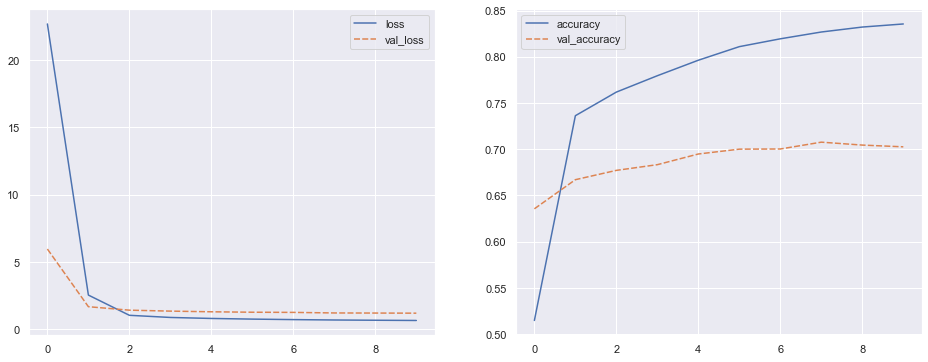

In [38]:
plt.figure(figsize=(16, 6))
plt.subplot(121)
sns.lineplot(data=history_d.loc[:10, ['loss', 'val_loss']])

plt.subplot(122)
sns.lineplot(data=history_d.loc[:30, ['accuracy', 'val_accuracy']]);

**Atividade (1 pt):** avalie os modelos treinados e compare com os resultados anteriores.

In [39]:
probabilities = model_dropout_reg.predict(x_test.toarray())
predictions = probabilities.argmax(axis=1)

print(classification_report(ye_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.67      0.74      4058
           1       0.63      0.79      0.70      4902
           2       0.51      0.79      0.62      8604
           3       0.00      0.00      0.00      7620
           4       0.77      0.91      0.83     13884
           5       0.92      0.92      0.92     10279

    accuracy                           0.72     49347
   macro avg       0.61      0.68      0.64     49347
weighted avg       0.63      0.72      0.66     49347



In [40]:
# acurácia para cada classe
matrix = confusion_matrix(y_ohe_test.argmax(axis=1), probabilities.argmax(axis=1))
(matrix.diagonal()/matrix.sum(axis=1)).round(3)

array([0.67 , 0.795, 0.787, 0.   , 0.907, 0.915])

Accuracy: 0.717
Accuracy (balanced): 0.679


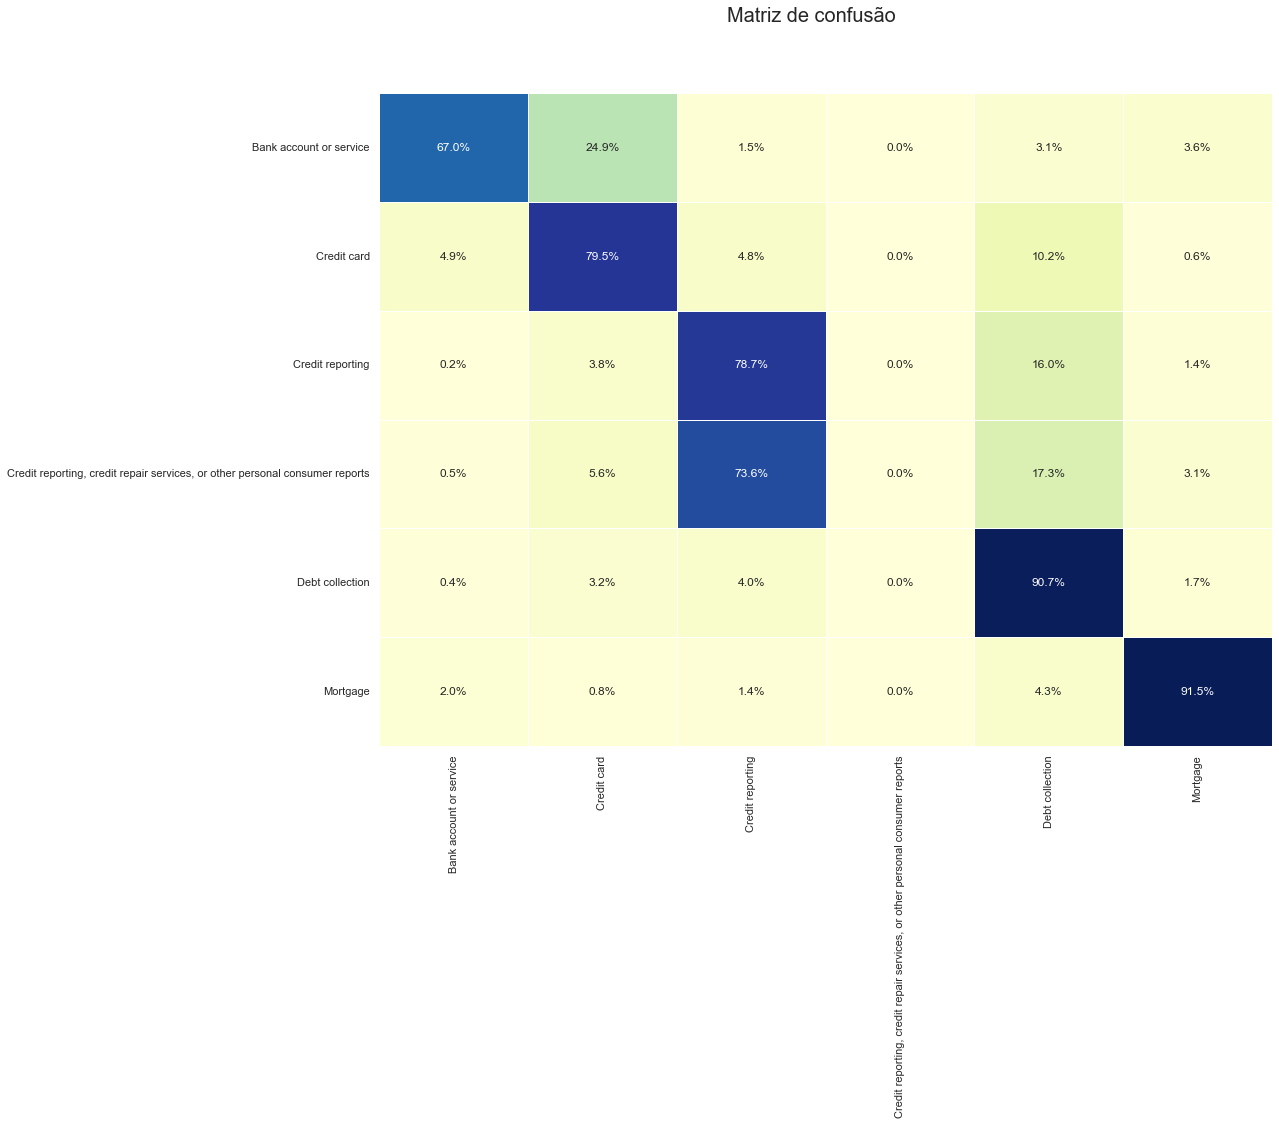

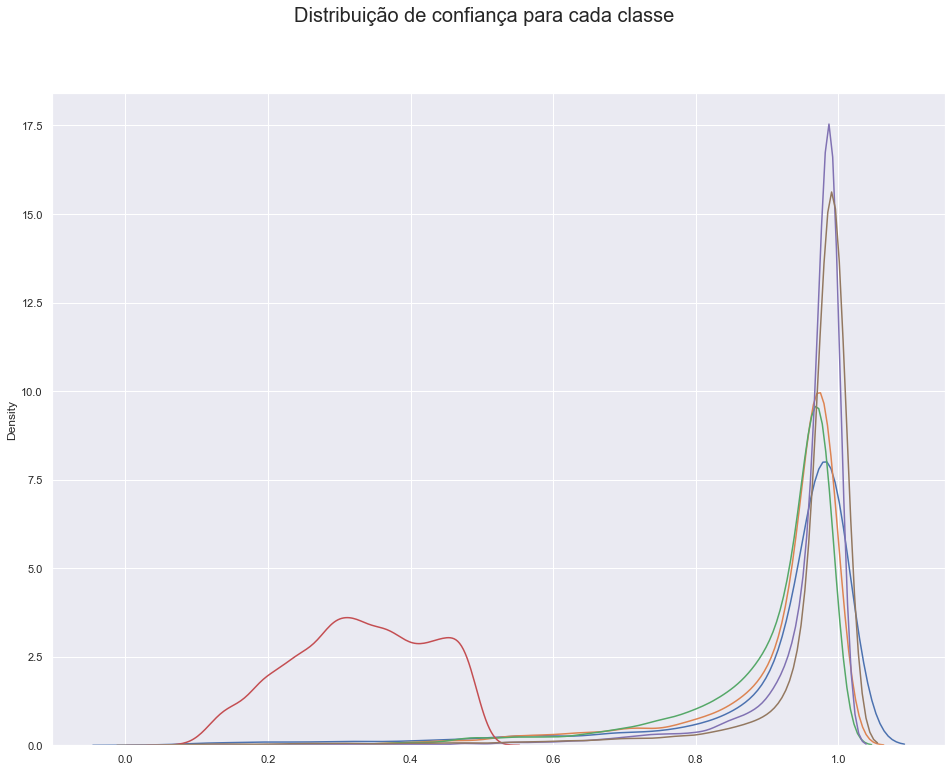

In [41]:
# Matriz de Confusão
evaluate(y_ohe_test.argmax(axis=1), predictions, probabilities, labels=label_enc.classes_)

A rede neural mais complexa com dropout e regularização obteve resultados muito semelhantes aos resultados da rede neural simples, porém inferiores. Isto acontece, pois a cada camada adicionada à rede neural, o modelo tende a se tornar superespecialista, levando ao overfitting.

Comparando com a regressão logística e rede neural simples, ambas tiveram valores de acurácia muito parecidos, porém a regressão logística obteve acurácia melhor na classe "Credit reporting: credit repair services, or other personal consumer reports".

Ao analisarmos a distribuição de confiança, a rede mais complexa mostrou melhor confiança na predição das classes. Contudo, a primeira rede neural se mostrou muito melhor que os outros modelos, a maioria das classes ficaram muito perto 1, além de que a classe pouco confiável nos demais modelos, se mostrou menos densa, porém com valor mais confiável dos que as demais.